# MRI-Based Brain Tumour Feature Extraction

### Pilot Analysis — 3D MRI Radiomics & Feature Extraction

This project develops a reproducible 3D MRI preprocessing and quantitative feature-extraction pipeline for brain tumour research using multi-modal MRI data.

**Pilot subject:** `BraTS20_Training_001`
**Modalities:** FLAIR, T1, T1Gd, T2
**Dataset:** BraTS 2020

The pilot establishes and validates the feature-extraction workflow before extending the pipeline to the complete dataset. Extracted features include tumour geometry, intensity statistics, and 3D texture features for subsequent automated analysis, machine learning, and biological/pathway-level investigation.


In [1]:
import sys
print(sys.version)

3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]


In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Backend:", matplotlib.get_backend())

NumPy: 2.5.3
Pandas: 2.3.3
Matplotlib: 3.11.2
Backend: module://matplotlib_inline.backend_inline


In [3]:
import nibabel as nib
import nilearn

print("NiBabel:", nib.__version__)
print("Nilearn:", nilearn.__version__)

NiBabel: 5.4.2
Nilearn: 0.14.1


In [4]:
import sklearn
import xgboost
import shap

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

scikit-learn: 1.9.1
XGBoost: 3.4.1
SHAP: 0.52.0


In [5]:
import gseapy
import mygene
import networkx as nx

print("GSEApy:", gseapy.__version__)
print("MyGene:", mygene.__version__)
print("NetworkX:", nx.__version__)

GSEApy: 1.3.1
MyGene: 3.2.2
NetworkX: 3.7


In [6]:
import lifelines
print("Lifelines:", lifelines.__version__)

Lifelines: 0.30.3


In [7]:
from pathlib import Path

In [8]:
data_path = Path("../data/raw/BraTS-TCGA-GBM")

In [9]:
print(data_path)
print(data_path.exists())

..\data\raw\BraTS-TCGA-GBM
True


In [10]:
items = list(data_path.iterdir())

for item in items:
    print(item.name)

extracted
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations.zip


In [11]:
import zipfile

zip_path = data_path / "Pre-operative_TCGA_GBM_NIfTI_and_Segmentations.zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    files = zip_file.namelist()

print("Number of files:", len(files))

for file in files[:20]:
    print(file)

Number of files: 711
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_GlistrBoost.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_GlistrBoost_ManuallyCorrected.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_flair.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_t1.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_t1Gd.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_t2.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0009/
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0009/TCGA-02-0009_1997.06.14_GlistrBoost.nii.gz
Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0009/TCGA-02-0009_1997.06.14_GlistrBoost_Manua

In [12]:
patient_ids = set()

for file in files:
    parts = Path(file).parts
    
    if len(parts) >= 2 and parts[1].startswith("TCGA-"):
        patient_ids.add(parts[1])

print("Number of patients:", len(patient_ids))
print("First 10 patients:")

for patient in sorted(patient_ids)[:10]:
    print(patient)

Number of patients: 102
First 10 patients:
TCGA-02-0006
TCGA-02-0009
TCGA-02-0011
TCGA-02-0027
TCGA-02-0033
TCGA-02-0034
TCGA-02-0037
TCGA-02-0046
TCGA-02-0047
TCGA-02-0054


In [13]:
expected_files = ["flair", "t1", "t1Gd", "t2", "GlistrBoost", "GlistrBoost_ManuallyCorrected"]

patient_files = {patient: [] for patient in patient_ids}

for file in files:
    parts = Path(file).parts
    
    if len(parts) >= 3 and parts[1] in patient_files:
        patient_files[parts[1]].append(parts[2])

for patient in sorted(patient_files):
    print(patient)
    for expected in expected_files:
        found = any(expected in filename for filename in patient_files[patient])
        print(f"  {expected}: {'✓' if found else '✗'}")

TCGA-02-0006
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0009
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0011
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0027
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0033
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0034
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0037
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0046
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0047
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_ManuallyCorrected: ✓
TCGA-02-0054
  flair: ✓
  t1: ✓
  t1Gd: ✓
  t2: ✓
  GlistrBoost: ✓
  GlistrBoost_M

In [86]:
from zipfile import ZipFile
from pathlib import Path

zip_path = Path("../data/raw/BraTS-TCGA-GBM/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations.zip")
extract_path = Path("../data/raw/BraTS-TCGA-GBM/extracted")

extract_path.mkdir(parents=True, exist_ok=True)

with ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(extract_path)

print("Extraction complete!")
print("Location:", extract_path)

Extraction complete!
Location: ..\data\raw\BraTS-TCGA-GBM\extracted


In [15]:
from pathlib import Path

data_path = Path("../data/raw/BraTS-TCGA-GBM/extracted")

print("Extraction folder exists:", data_path.exists())

patients_path = next(data_path.iterdir())

print("Main folder:", patients_path.name)
print("Number of patient folders:", len(list(patients_path.iterdir())))

Extraction folder exists: True
Main folder: Pre-operative_TCGA_GBM_NIfTI_and_Segmentations
Number of patient folders: 103


In [16]:
import nibabel as nib
from pathlib import Path

patient = "TCGA-02-0006"

mri_path = next(
    (Path("../data/raw/BraTS-TCGA-GBM/extracted")
     / "Pre-operative_TCGA_GBM_NIfTI_and_Segmentations"
     / patient).glob("*_flair.nii.gz")
)

print("MRI file:", mri_path)

MRI file: ..\data\raw\BraTS-TCGA-GBM\extracted\Pre-operative_TCGA_GBM_NIfTI_and_Segmentations\TCGA-02-0006\TCGA-02-0006_1996.08.23_flair.nii.gz


In [17]:
patient_folder = (
    Path("../data/raw/BraTS-TCGA-GBM/extracted")
    / "Pre-operative_TCGA_GBM_NIfTI_and_Segmentations"
    / patient
)

In [18]:
mri = nib.load(mri_path)

In [19]:
print(mri)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (240, 240, 155)
affine:
[[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : aligned
sform_code      : scanner
quatern_b   

In [20]:
data = mri.get_fdata()

In [21]:
print("Shape:", data.shape)
print("Minimum:", data.min())
print("Maximum:", data.max())

Shape: (240, 240, 155)
Minimum: 0.0
Maximum: 470.0


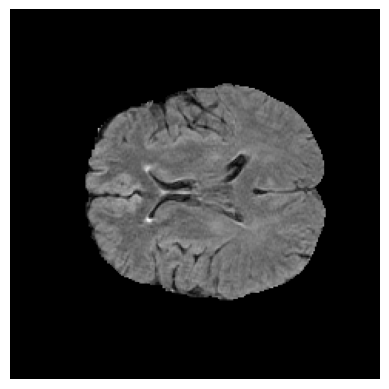

In [22]:
import matplotlib.pyplot as plt

slice_index = data.shape[2] // 2

plt.imshow(data[:, :, slice_index], cmap="gray")
plt.axis("off")
plt.show()

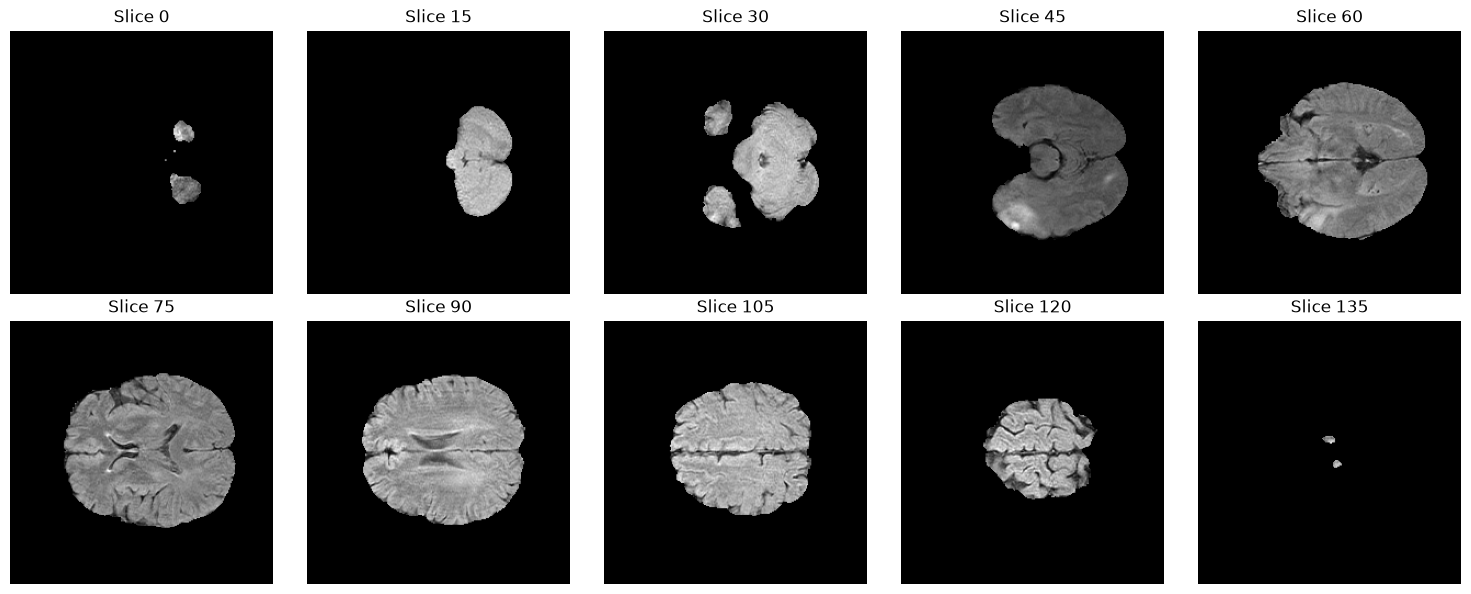

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    slice_index = i * 15
    ax.imshow(data[:, :, slice_index], cmap="gray")
    ax.set_title(f"Slice {slice_index}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
import skimage
print(skimage.__version__)

0.26.0


In [1]:
# import plotly.graph_objects as go

# fig = go.Figure()

# fig.add_trace(
#     go.Heatmap(
#         z=data[:, :, 77],
#         colorscale="Gray",
#         zmin=data.min(),
#         zmax=data.max()
#     )
# )

# steps = []

# for i in range(data.shape[2]):
#     steps.append(
#         dict(
#             method="restyle",
#             args=["z", [data[:, :, i]]],
#             label=str(i)
#         )
#     )

# fig.update_layout(
#     title="FLAIR MRI — Axial Slices",
#     width=800,
#     height=800,
#     xaxis_title="X",
#     yaxis_title="Y",

#     yaxis=dict(
#         scaleanchor="x",
#         scaleratio=1
#     ),

#     sliders=[
#         dict(
#             active=77,
#             currentvalue={"prefix": "Slice: "},
#             steps=steps
#         )
#     ]
# )

# fig.show()


#### This section was commented out due to GitHub upload limit of Jupyter Notebook

In [26]:
seg_path = mri_path.parent / f"{patient}_1996.08.23_GlistrBoost_ManuallyCorrected.nii.gz"

print("Segmentation file:", seg_path)
print("Exists:", seg_path.exists())

Segmentation file: ..\data\raw\BraTS-TCGA-GBM\extracted\Pre-operative_TCGA_GBM_NIfTI_and_Segmentations\TCGA-02-0006\TCGA-02-0006_1996.08.23_GlistrBoost_ManuallyCorrected.nii.gz
Exists: True


In [27]:
seg = nib.load(seg_path)
print(seg)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (240, 240, 155)
affine:
[[ -1.  -0.  -0.  -0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b    

In [28]:
seg_data = seg.get_fdata()

print("Shape:", seg_data.shape)
print("Unique values:", np.unique(seg_data))

Shape: (240, 240, 155)
Unique values: [0. 1. 2. 4.]


In [29]:
import numpy as np

for label in [0, 1, 2, 4]:
    print(f"Label {label}: {(seg_data == label).sum()} voxels")

Label 0: 8889686 voxels
Label 1: 384 voxels
Label 2: 36268 voxels
Label 4: 1662 voxels


In [30]:
tumor_mask = seg_data > 0
print("Tumour voxels:", tumor_mask.sum())

tumor_per_slice = tumor_mask.sum(axis=(0, 1))

best_slice = tumor_per_slice.argmax()

print("Slice with most tumour:", best_slice)
print("Tumour voxels in that slice:", tumor_per_slice[best_slice])

Tumour voxels: 38314
Slice with most tumour: 45
Tumour voxels in that slice: 1783


In [31]:
print(np.unique(seg_data))
print(seg.header)

[0. 1. 2. 4.]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 1.0
qoffset_x       : -0.0
qoffset_y       : 239.0
qoffset_z       : 0.0
srow_x          : [-1. -0. -0. -0.]
srow

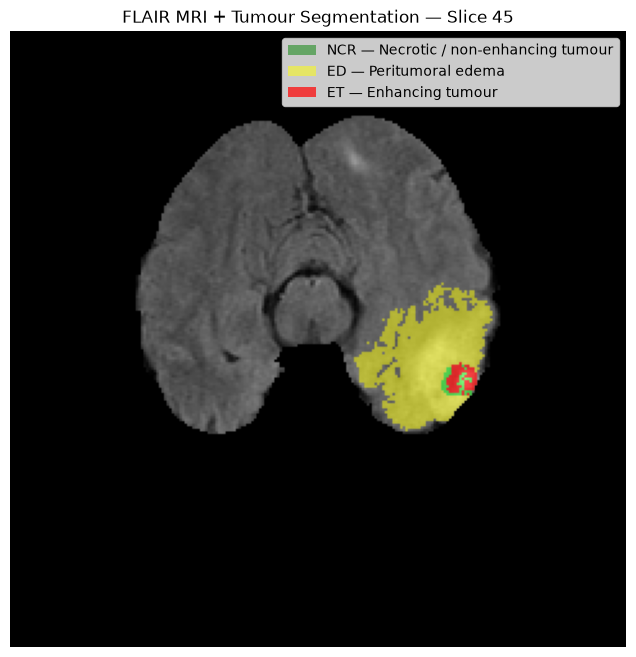

In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(8, 8))

plt.imshow(
    data[:, :, 45].T,
    cmap="gray",
    origin="lower"
)

seg_slice = seg_data[:, :, 45].T
overlay = np.zeros((*seg_slice.shape, 4))

overlay[seg_slice == 1] = [0, 1, 0, 0.5]
overlay[seg_slice == 2] = [1, 1, 0, 0.5]
overlay[seg_slice == 4] = [1, 0, 0, 0.7]

plt.imshow(overlay, origin="lower")

legend_elements = [
    Patch(facecolor="green", alpha=0.5, label="NCR — Necrotic / non-enhancing tumour"),
    Patch(facecolor="yellow", alpha=0.5, label="ED — Peritumoral edema"),
    Patch(facecolor="red", alpha=0.7, label="ET — Enhancing tumour")
]

plt.legend(handles=legend_elements, loc="upper right")

plt.title("FLAIR MRI + Tumour Segmentation — Slice 45")
plt.axis("off")
plt.show()

In [33]:
label_counts = {
    "NCR": np.sum(seg_data == 1),
    "ED": np.sum(seg_data == 2),
    "ET": np.sum(seg_data == 4)
}

for label, count in label_counts.items():
    print(f"{label}: {count:,} voxels")


    voxel_volume_mm3 = np.prod(seg.header.get_zooms()[:3])

for label, count in label_counts.items():
    volume_mm3 = count * voxel_volume_mm3
    volume_cm3 = volume_mm3 / 1000
    print(f"{label}: {volume_cm3:.2f} cm³")

NCR: 384 voxels
ED: 36,268 voxels
ET: 1,662 voxels
NCR: 0.38 cm³
ED: 36.27 cm³
ET: 1.66 cm³


In [34]:
total_tumor_voxels = np.sum(seg_data > 0)

total_volume_mm3 = total_tumor_voxels * voxel_volume_mm3
total_volume_cm3 = total_volume_mm3 / 1000

print("Total segmented voxels:", total_tumor_voxels)
print(f"Total segmented volume: {total_volume_cm3:.2f} cm³")

Total segmented voxels: 38314
Total segmented volume: 38.31 cm³


In [35]:
modalities = ["t1", "t1Gd", "t2"]

for modality in modalities:
    path = next(patient_folder.glob(f"*_{modality}.nii.gz"))
    img = nib.load(path)
    
    print(f"{modality}:")
    print("  Shape:", img.shape)
    print("  Voxel size:", img.header.get_zooms()[:3])

t1:
  Shape: (240, 240, 155)
  Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
t1Gd:
  Shape: (240, 240, 155)
  Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
t2:
  Shape: (240, 240, 155)
  Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


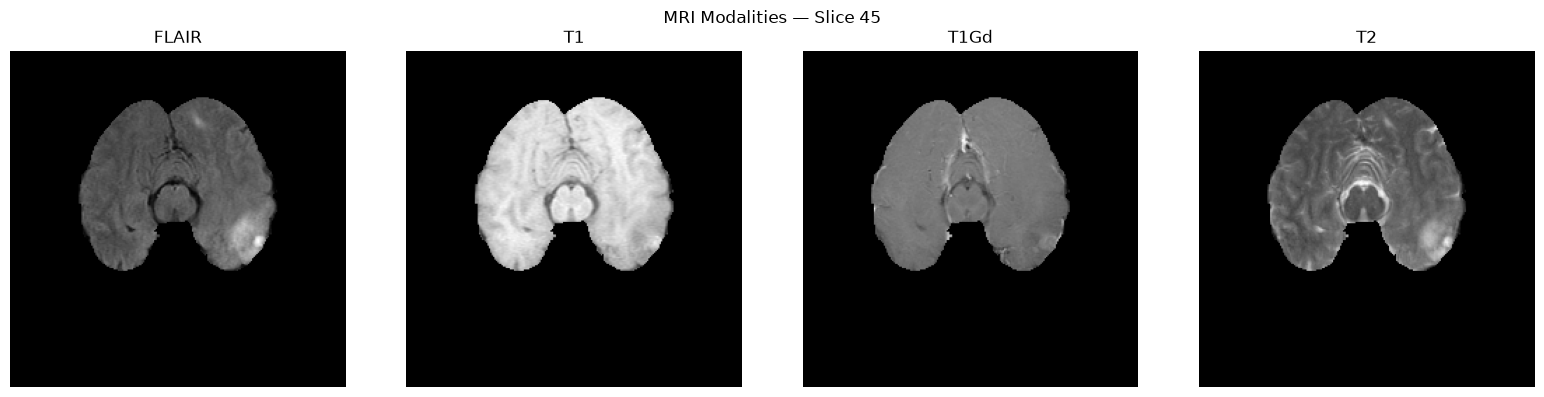

In [36]:
modality_files = {
    "FLAIR": mri_path,
    "T1": next(patient_folder.glob("*_t1.nii.gz")),
    "T1Gd": next(patient_folder.glob("*_t1Gd.nii.gz")),
    "T2": next(patient_folder.glob("*_t2.nii.gz"))
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (modality, path) in zip(axes, modality_files.items()):
    image_data = nib.load(path).get_fdata()
    ax.imshow(image_data[:, :, 45].T, cmap="gray", origin="lower")
    ax.set_title(modality)
    ax.axis("off")

plt.suptitle("MRI Modalities — Slice 45")
plt.tight_layout()
plt.show()

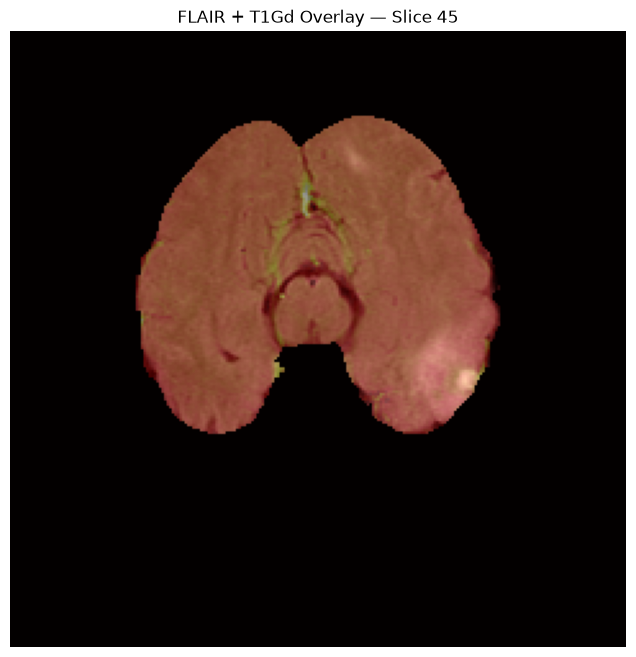

In [37]:
t1gd_data = nib.load(modality_files["T1Gd"]).get_fdata()

plt.figure(figsize=(8, 8))

plt.imshow(
    data[:, :, 45].T,
    cmap="gray",
    origin="lower"
)

plt.imshow(
    t1gd_data[:, :, 45].T,
    cmap="hot",
    alpha=0.35,
    origin="lower"
)

plt.title("FLAIR + T1Gd Overlay — Slice 45")
plt.axis("off")
plt.show()

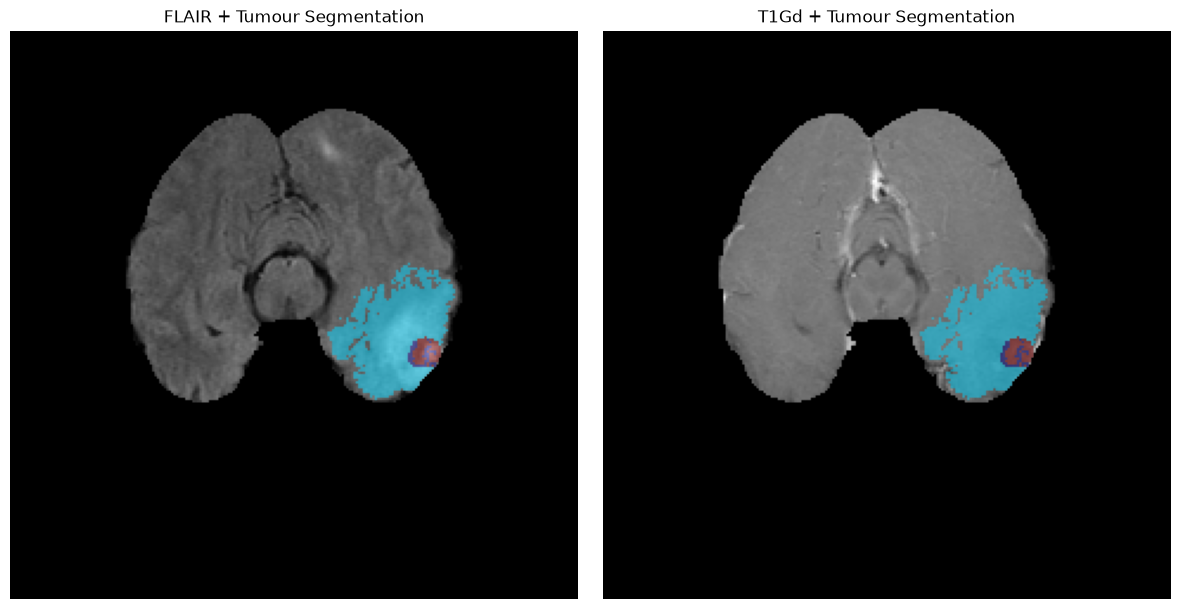

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(data[:, :, 45].T, cmap="gray", origin="lower")
axes[0].imshow(
    np.ma.masked_where(seg_data[:, :, 45].T == 0, seg_data[:, :, 45].T),
    cmap="jet",
    alpha=0.5,
    origin="lower"
)
axes[0].set_title("FLAIR + Tumour Segmentation")
axes[0].axis("off")

axes[1].imshow(t1gd_data[:, :, 45].T, cmap="gray", origin="lower")
axes[1].imshow(
    np.ma.masked_where(seg_data[:, :, 45].T == 0, seg_data[:, :, 45].T),
    cmap="jet",
    alpha=0.5,
    origin="lower"
)
axes[1].set_title("T1Gd + Tumour Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

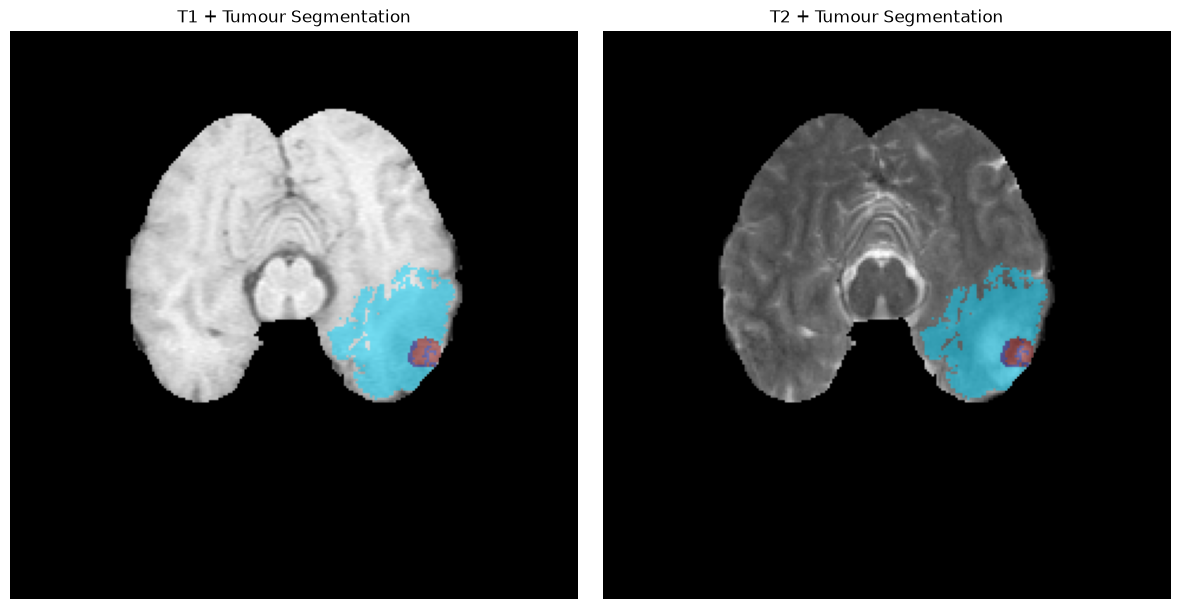

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(
    nib.load(modality_files["T1"]).get_fdata()[:, :, 45].T,
    cmap="gray",
    origin="lower"
)
axes[0].imshow(
    np.ma.masked_where(seg_data[:, :, 45].T == 0, seg_data[:, :, 45].T),
    cmap="jet",
    alpha=0.5,
    origin="lower"
)
axes[0].set_title("T1 + Tumour Segmentation")
axes[0].axis("off")

axes[1].imshow(
    nib.load(modality_files["T2"]).get_fdata()[:, :, 45].T,
    cmap="gray",
    origin="lower"
)
axes[1].imshow(
    np.ma.masked_where(seg_data[:, :, 45].T == 0, seg_data[:, :, 45].T),
    cmap="jet",
    alpha=0.5,
    origin="lower"
)
axes[1].set_title("T2 + Tumour Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [40]:
for modality, path in modality_files.items():
    image_data = nib.load(path).get_fdata()

    print(f"{modality}:")
    print("  Minimum:", image_data.min())
    print("  Maximum:", image_data.max())

FLAIR:
  Minimum: 0.0
  Maximum: 470.0
T1:
  Minimum: 0.0
  Maximum: 502.0
T1Gd:
  Minimum: 0.0
  Maximum: 1162.0
T2:
  Minimum: 0.0
  Maximum: 828.0


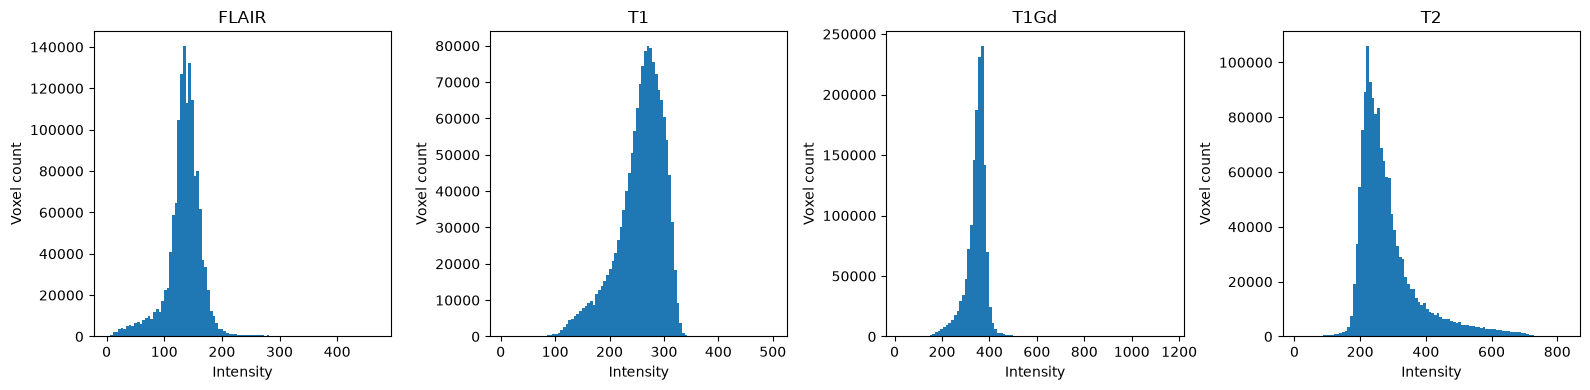

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (modality, path) in zip(axes, modality_files.items()):
    image_data = nib.load(path).get_fdata()

    ax.hist(image_data[image_data > 0].ravel(), bins=100)
    ax.set_title(modality)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Voxel count")

plt.tight_layout()
plt.show()

In [42]:
for modality, path in modality_files.items():
    image_data = nib.load(path).get_fdata()
    brain_voxels = image_data[image_data > 0]

    p1 = np.percentile(brain_voxels, 1)
    p99 = np.percentile(brain_voxels, 99)

    print(f"{modality}:")
    print(f"  1st percentile:  {p1:.2f}")
    print(f"  99th percentile: {p99:.2f}")

FLAIR:
  1st percentile:  31.00
  99th percentile: 210.00
T1:
  1st percentile:  127.00
  99th percentile: 324.00
T1Gd:
  1st percentile:  195.00
  99th percentile: 438.00
T2:
  1st percentile:  172.00
  99th percentile: 643.00


In [43]:
flair = data.copy()

p1 = np.percentile(flair[flair > 0], 1)
p99 = np.percentile(flair[flair > 0], 99)

flair_normalized = np.clip(flair, p1, p99)
flair_normalized = (flair_normalized - p1) / (p99 - p1)

flair_normalized[flair == 0] = 0

print("Minimum:", flair_normalized.min())
print("Maximum:", flair_normalized.max())

Minimum: 0.0
Maximum: 1.0


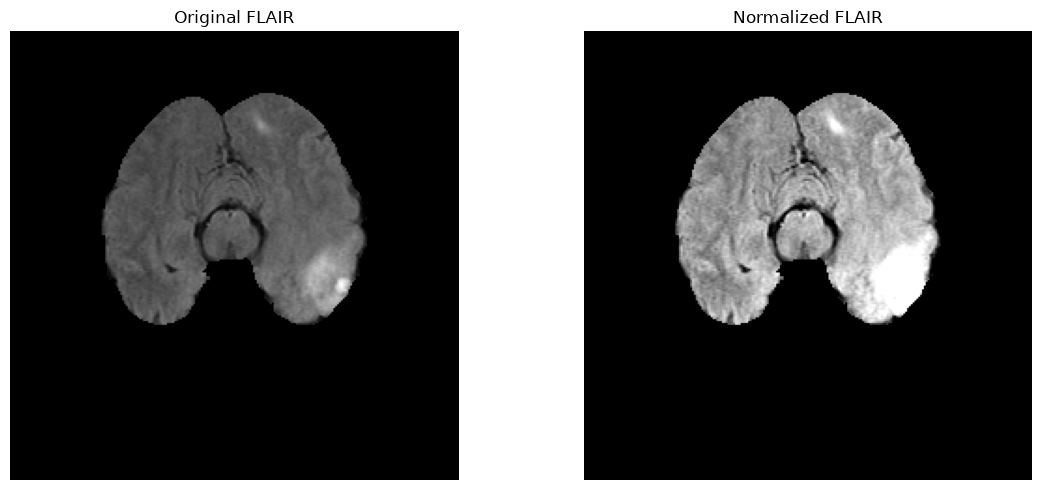

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(data[:, :, 45].T, cmap="gray", origin="lower")
axes[0].set_title("Original FLAIR")
axes[0].axis("off")

axes[1].imshow(flair_normalized[:, :, 45].T, cmap="gray", origin="lower")
axes[1].set_title("Normalized FLAIR")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [45]:
def normalize_mri(image):
    brain_voxels = image[image > 0]

    p1 = np.percentile(brain_voxels, 1)
    p99 = np.percentile(brain_voxels, 99)

    normalized = np.clip(image, p1, p99)
    normalized = (normalized - p1) / (p99 - p1)

    normalized[image == 0] = 0

    return normalized

In [46]:
normalized_images = {}

for modality, path in modality_files.items():
    image = nib.load(path).get_fdata()
    normalized_images[modality] = normalize_mri(image)

    print(
        f"{modality}:",
        normalized_images[modality].min(),
        normalized_images[modality].max()
    )

FLAIR: 0.0 1.0
T1: 0.0 1.0
T1Gd: 0.0 1.0
T2: 0.0 1.0


In [47]:
tumour_mask = seg_data > 0

print("Mask shape:", tumour_mask.shape)
print("Tumour voxels:", tumour_mask.sum())
print("Background voxels:", (~tumour_mask).sum())

Mask shape: (240, 240, 155)
Tumour voxels: 38314
Background voxels: 8889686


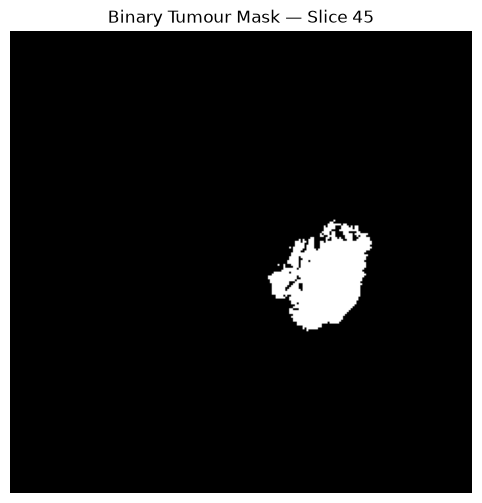

In [48]:
plt.figure(figsize=(6, 6))

plt.imshow(
    tumour_mask[:, :, 45].T,
    cmap="gray",
    origin="lower"
)

plt.title("Binary Tumour Mask — Slice 45")
plt.axis("off")
plt.show()

In [49]:
tumour_features = {}

for modality, image in normalized_images.items():
    tumour_values = image[tumour_mask]

    tumour_features[modality] = {
        "mean": np.mean(tumour_values),
        "median": np.median(tumour_values),
        "std": np.std(tumour_values),
        "min": np.min(tumour_values),
        "max": np.max(tumour_values)
    }

tumour_features

{'FLAIR': {'mean': np.float64(0.8999359307667341),
  'median': np.float64(0.8994413407821229),
  'std': np.float64(0.09192837518845405),
  'min': np.float64(0.4748603351955307),
  'max': np.float64(1.0)},
 'T1': {'mean': np.float64(0.608783843045272),
  'median': np.float64(0.6091370558375635),
  'std': np.float64(0.11180433775507523),
  'min': np.float64(0.116751269035533),
  'max': np.float64(0.9796954314720813)},
 'T1Gd': {'mean': np.float64(0.5687273087382128),
  'median': np.float64(0.5679012345679012),
  'std': np.float64(0.10121077578175842),
  'min': np.float64(0.0),
  'max': np.float64(1.0)},
 'T2': {'mean': np.float64(0.3223997658414706),
  'median': np.float64(0.2908704883227176),
  'std': np.float64(0.13412939860999556),
  'min': np.float64(0.04670912951167728),
  'max': np.float64(1.0)}}

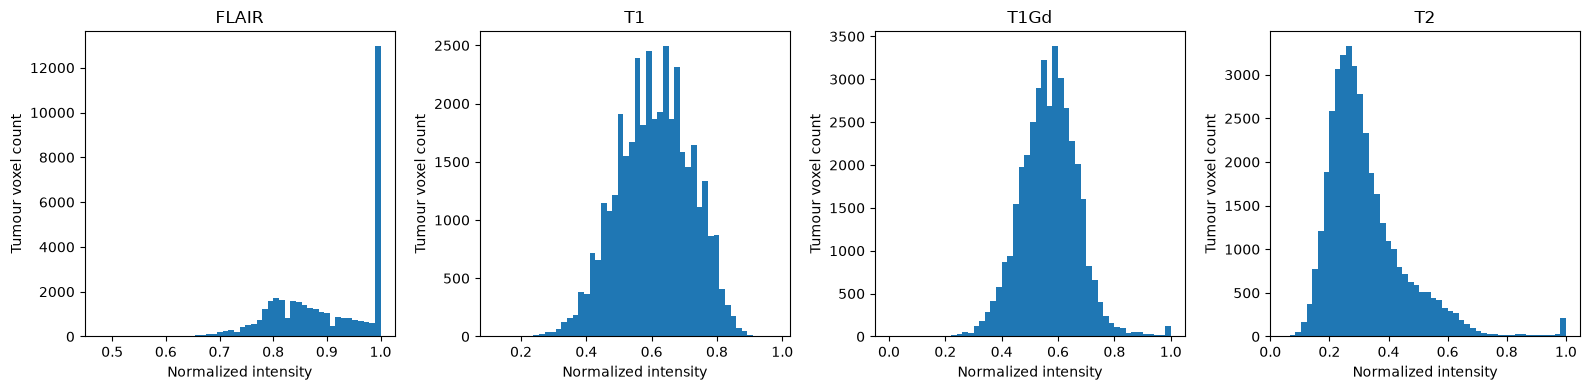

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (modality, image) in zip(axes, normalized_images.items()):
    tumour_values = image[tumour_mask]

    ax.hist(tumour_values, bins=50)
    ax.set_title(modality)
    ax.set_xlabel("Normalized intensity")
    ax.set_ylabel("Tumour voxel count")

plt.tight_layout()
plt.show()

In [51]:
tumour_coords = np.argwhere(tumour_mask)

volume_voxels = tumour_mask.sum()

min_coords = tumour_coords.min(axis=0)
max_coords = tumour_coords.max(axis=0)

bounding_box = max_coords - min_coords + 1

centroid = tumour_coords.mean(axis=0)

print("Tumour volume (voxels):", volume_voxels)
print("Bounding box (voxels):", bounding_box)
print("Centroid (x, y, z):", centroid)

Tumour volume (voxels): 38314
Bounding box (voxels): [58 59 48]
Centroid (x, y, z): [162.35172522 110.37876494  48.60706269]


In [52]:
import skimage
print(skimage.__version__)

0.26.0


In [53]:
from skimage.measure import marching_cubes

verts, faces, _, _ = marching_cubes(
    tumour_mask.astype(float),
    level=0.5,
    spacing=(1, 1, 1)
)

surface_area = 0

for face in faces:
    triangle = verts[face]

    a = triangle[1] - triangle[0]
    b = triangle[2] - triangle[0]

    triangle_area = 0.5 * np.linalg.norm(np.cross(a, b))
    surface_area += triangle_area

print("Tumour surface area:", surface_area, "mm²")

Tumour surface area: 14430.063 mm²


In [54]:
volume = tumour_mask.sum()
surface_area = surface_area

sphericity = (
    np.pi ** (1/3)
    * (6 * volume) ** (2/3)
    / surface_area
)

print("Tumour sphericity:", sphericity)

Tumour sphericity: 0.3808794542981205


In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(tumour_coords)

spread = np.sqrt(pca.explained_variance_)

elongation = spread[0] / spread[1]

print("Tumour elongation:", elongation)

Tumour elongation: 1.1505380825596834


In [57]:
texture_features = {}

for modality, image in normalized_images.items():
    tumour_values = image[tumour_mask]

    mean = np.mean(tumour_values)
    std = np.std(tumour_values)

    cv = std / mean

    texture_features[modality] = {
        "mean": mean,
        "std": std,
        "coefficient_of_variation": cv
    }

for modality, features in texture_features.items():
    print(f"{modality}:")
    print(f"  Mean: {features['mean']:.3f}")
    print(f"  Std: {features['std']:.3f}")
    print(f"  CV: {features['coefficient_of_variation']:.3f}")

FLAIR:
  Mean: 0.900
  Std: 0.092
  CV: 0.102
T1:
  Mean: 0.609
  Std: 0.112
  CV: 0.184
T1Gd:
  Mean: 0.569
  Std: 0.101
  CV: 0.178
T2:
  Mean: 0.322
  Std: 0.134
  CV: 0.416


In [58]:
from scipy.ndimage import convolve

texture_features = {}

for modality, image in normalized_images.items():

    tumour_values = image[tumour_mask]

    neighbour_sum = convolve(
        image,
        np.ones((3, 3, 3)),
        mode="constant",
        cval=0
    )

    neighbour_count = convolve(
        tumour_mask.astype(float),
        np.ones((3, 3, 3)),
        mode="constant",
        cval=0
    )

    neighbour_mean = neighbour_sum / np.maximum(neighbour_count, 1)

    differences = np.abs(image - neighbour_mean)

    contrast = np.mean(differences[tumour_mask])

    texture_features[modality] = contrast

for modality, contrast in texture_features.items():
    print(f"{modality}: {contrast:.3f}")

FLAIR: 0.174
T1: 0.140
T1Gd: 0.136
T2: 0.068


In [59]:
from skimage.feature import graycomatrix, graycoprops

flair_tumour = normalized_images["FLAIR"][tumour_mask]
print("Tumour voxels:", len(flair_tumour))

Tumour voxels: 38314


In [60]:
n_levels = 8

flair_quantized = np.floor(
    flair_tumour * n_levels
).astype(np.uint8)

flair_quantized = np.clip(
    flair_quantized,
    0,
    n_levels - 1
)

print("Unique gray levels:", np.unique(flair_quantized))

Unique gray levels: [3 4 5 6 7]


In [61]:
flair_quantized_3d = np.zeros_like(seg_data, dtype=np.uint8)

flair_quantized_3d[tumour_mask] = flair_quantized

print("Shape:", flair_quantized_3d.shape)

Shape: (240, 240, 155)


In [62]:
from skimage.feature import graycomatrix, graycoprops

slice_45 = flair_quantized_3d[:, :, 45]

glcm = graycomatrix(
    slice_45,
    distances=[1],
    angles=[0],
    levels=8,
    symmetric=True,
    normed=True
)

print("GLCM shape:", glcm.shape)

GLCM shape: (8, 8, 1, 1)


In [63]:
glcm_contrast = graycoprops(glcm, "contrast")[0, 0]
print("FLAIR GLCM contrast:", glcm_contrast)

FLAIR GLCM contrast: 0.1544979079497908


In [64]:
glcm_homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
glcm_energy = graycoprops(glcm, "energy")[0, 0]

print("FLAIR GLCM homogeneity:", glcm_homogeneity)
print("FLAIR GLCM energy:", glcm_energy)

FLAIR GLCM homogeneity: 0.9936708440298151
FLAIR GLCM energy: 0.9670089686397592


In [65]:
glcm_correlation = graycoprops(glcm, "correlation")[0, 0]
print("FLAIR GLCM correlation:", glcm_correlation)

FLAIR GLCM correlation: 0.9409055946878632


In [66]:
glcm_features = {}

for modality, image in normalized_images.items():

    quantized = np.floor(image * 8).astype(np.uint8)
    quantized = np.clip(quantized, 0, 7)

    slice_45 = quantized[:, :, 45]

    glcm = graycomatrix(
        slice_45,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    glcm_features[modality] = {
        "contrast": graycoprops(glcm, "contrast")[0, 0],
        "homogeneity": graycoprops(glcm, "homogeneity")[0, 0],
        "energy": graycoprops(glcm, "energy")[0, 0],
        "correlation": graycoprops(glcm, "correlation")[0, 0]
    }

for modality, features in glcm_features.items():
    print(f"{modality}:")
    for name, value in features.items():
        print(f"  {name}: {value:.4f}")

FLAIR:
  contrast: 0.1857
  homogeneity: 0.9560
  energy: 0.7762
  correlation: 0.9775
T1:
  contrast: 0.1517
  homogeneity: 0.9592
  energy: 0.7782
  correlation: 0.9828
T1Gd:
  contrast: 0.1880
  homogeneity: 0.9579
  energy: 0.7773
  correlation: 0.9748
T2:
  contrast: 0.1070
  homogeneity: 0.9647
  energy: 0.8277
  correlation: 0.9086


In [67]:
mask_slice = tumour_mask[:, :, 45]
image_slice = normalized_images["FLAIR"][:, :, 45]

tumour_slice = np.zeros_like(image_slice)
tumour_slice[mask_slice] = image_slice[mask_slice]

print("Tumour pixels:", np.sum(mask_slice))

Tumour pixels: 1783


In [68]:
tumour_coords = np.argwhere(tumour_mask)

print("Tumour voxels:", len(tumour_coords))
print("X range:", tumour_coords[:, 0].min(), "to", tumour_coords[:, 0].max())
print("Y range:", tumour_coords[:, 1].min(), "to", tumour_coords[:, 1].max())
print("Z range:", tumour_coords[:, 2].min(), "to", tumour_coords[:, 2].max())

Tumour voxels: 38314
X range: 131 to 188
Y range: 84 to 142
Z range: 29 to 76


In [69]:
x_min, x_max = tumour_coords[:, 0].min(), tumour_coords[:, 0].max()
y_min, y_max = tumour_coords[:, 1].min(), tumour_coords[:, 1].max()
z_min, z_max = tumour_coords[:, 2].min(), tumour_coords[:, 2].max()

print("Tumour bounding box:")
print("X:", x_min, "to", x_max)
print("Y:", y_min, "to", y_max)
print("Z:", z_min, "to", z_max)

Tumour bounding box:
X: 131 to 188
Y: 84 to 142
Z: 29 to 76


In [70]:
cropped_images = {}

for modality, image in normalized_images.items():
    cropped_images[modality] = image[
        x_min:x_max + 1,
        y_min:y_max + 1,
        z_min:z_max + 1
    ]

cropped_mask = tumour_mask[
    x_min:x_max + 1,
    y_min:y_max + 1,
    z_min:z_max + 1
]

for modality, image in cropped_images.items():
    print(f"{modality} shape:", image.shape)

print("Mask shape:", cropped_mask.shape)

FLAIR shape: (58, 59, 48)
T1 shape: (58, 59, 48)
T1Gd shape: (58, 59, 48)
T2 shape: (58, 59, 48)
Mask shape: (58, 59, 48)


In [71]:
print("Cropped mask tumour voxels:", np.sum(cropped_mask))
print("Cropped mask shape:", cropped_mask.shape)

for modality, image in cropped_images.items():
    print(f"{modality}:", image.shape)

Cropped mask tumour voxels: 38314
Cropped mask shape: (58, 59, 48)
FLAIR: (58, 59, 48)
T1: (58, 59, 48)
T1Gd: (58, 59, 48)
T2: (58, 59, 48)


In [72]:
directions = [
    (1, 0, 0),
    (0, 1, 0),
    (0, 0, 1)
]

print("3D directions:", directions)

3D directions: [(1, 0, 0), (0, 1, 0), (0, 0, 1)]


In [73]:
quantized_images = {}

for modality, image in cropped_images.items():
    quantized = np.floor(image * 8).astype(np.uint8)
    quantized = np.clip(quantized, 0, 7)

    quantized_images[modality] = quantized

    print(f"{modality}:")
    print("  Shape:", quantized.shape)
    print("  Levels:", np.unique(quantized))

FLAIR:
  Shape: (58, 59, 48)
  Levels: [0 1 2 3 4 5 6 7]
T1:
  Shape: (58, 59, 48)
  Levels: [0 1 2 3 4 5 6 7]
T1Gd:
  Shape: (58, 59, 48)
  Levels: [0 1 2 3 4 5 6 7]
T2:
  Shape: (58, 59, 48)
  Levels: [0 1 2 3 4 5 6 7]


In [74]:
flair = quantized_images["FLAIR"]

glcm_3d = np.zeros((8, 8), dtype=np.float64)

for dx, dy, dz in directions:
    shifted = np.roll(flair, (-dx, -dy, -dz), axis=(0, 1, 2))
    
    valid = cropped_mask & np.roll(
        cropped_mask,
        (-dx, -dy, -dz),
        axis=(0, 1, 2)
    )

    i = flair[valid]
    j = shifted[valid]

    for a, b in zip(i, j):
        glcm_3d[a, b] += 1

glcm_3d = glcm_3d / glcm_3d.sum()

print("3D GLCM shape:", glcm_3d.shape)
print("GLCM sum:", glcm_3d.sum())

3D GLCM shape: (8, 8)
GLCM sum: 1.0000000000000002


In [76]:
i, j = np.meshgrid(
    np.arange(8),
    np.arange(8),
    indexing="ij"
)

contrast_3d = np.sum(
    glcm_3d * (i - j) ** 2
)

homogeneity_3d = np.sum(
    glcm_3d / (1 + np.abs(i - j))
)

energy_3d = np.sum(
    glcm_3d ** 2
) ** 0.5

print("FLAIR 3D GLCM contrast:", contrast_3d)
print("FLAIR 3D GLCM homogeneity:", homogeneity_3d)
print("FLAIR 3D GLCM energy:", energy_3d)

FLAIR 3D GLCM contrast: 0.17873723748057618
FLAIR 3D GLCM homogeneity: 0.9147862506395164
FLAIR 3D GLCM energy: 0.6172503953061423


In [77]:
mean_i = np.sum(i * glcm_3d)

mean_j = np.sum(j * glcm_3d)

std_i = np.sqrt(np.sum(((i - mean_i) ** 2) * glcm_3d))
std_j = np.sqrt(np.sum(((j - mean_j) ** 2) * glcm_3d))

correlation_3d = np.sum(
    ((i - mean_i) * (j - mean_j) * glcm_3d)
) / (std_i * std_j)

print("FLAIR 3D GLCM correlation:", correlation_3d)

FLAIR 3D GLCM correlation: 0.7354157095483387


In [78]:
glcm_3d_features = {}

for modality, image in quantized_images.items():

    glcm = np.zeros((8, 8), dtype=np.float64)

    for dx, dy, dz in directions:

        shifted = np.roll(
            image,
            (-dx, -dy, -dz),
            axis=(0, 1, 2)
        )

        shifted_mask = np.roll(
            cropped_mask,
            (-dx, -dy, -dz),
            axis=(0, 1, 2)
        )

        valid = cropped_mask & shifted_mask

        i_values = image[valid]
        j_values = shifted[valid]

        for a, b in zip(i_values, j_values):
            glcm[a, b] += 1

    glcm = glcm / glcm.sum()

    i, j = np.meshgrid(
        np.arange(8),
        np.arange(8),
        indexing="ij"
    )

    contrast = np.sum(
        glcm * (i - j) ** 2
    )

    homogeneity = np.sum(
        glcm / (1 + np.abs(i - j))
    )

    energy = np.sum(
        glcm ** 2
    ) ** 0.5

    mean_i = np.sum(i * glcm)
    mean_j = np.sum(j * glcm)

    std_i = np.sqrt(
        np.sum(((i - mean_i) ** 2) * glcm)
    )

    std_j = np.sqrt(
        np.sum(((j - mean_j) ** 2) * glcm)
    )

    correlation = np.sum(
        (i - mean_i) * (j - mean_j) * glcm
    ) / (std_i * std_j)

    glcm_3d_features[modality] = {
        "contrast": contrast,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation
    }

for modality, features in glcm_3d_features.items():
    print(f"\n{modality}:")
    for name, value in features.items():
        print(f"  {name}: {value:.4f}")


FLAIR:
  contrast: 0.1787
  homogeneity: 0.9148
  energy: 0.6173
  correlation: 0.7354

T1:
  contrast: 0.2445
  homogeneity: 0.8815
  energy: 0.4305
  correlation: 0.8596

T1Gd:
  contrast: 0.2729
  homogeneity: 0.8751
  energy: 0.4657
  correlation: 0.8088

T2:
  contrast: 0.2412
  homogeneity: 0.8875
  energy: 0.4496
  correlation: 0.9030


In [82]:
intensity_features = {}

for modality, image in normalized_images.items():

    tumour_values = image[tumour_mask]

    mean = np.mean(tumour_values)
    std = np.std(tumour_values)
    cv = std / mean

    intensity_features[modality] = {
        "mean": mean,
        "std": std,
        "cv": cv
    }

for modality, stats in intensity_features.items():
    print(f"{modality}:")
    print(f"  Mean: {stats['mean']:.3f}")
    print(f"  Std:  {stats['std']:.3f}")
    print(f"  CV:   {stats['cv']:.3f}")

FLAIR:
  Mean: 0.900
  Std:  0.092
  CV:   0.102
T1:
  Mean: 0.609
  Std:  0.112
  CV:   0.184
T1Gd:
  Mean: 0.569
  Std:  0.101
  CV:   0.178
T2:
  Mean: 0.322
  Std:  0.134
  CV:   0.416


In [83]:
import pandas as pd

features = {
    "tumour_volume_voxels": len(tumour_coords),

    "bbox_x": x_max - x_min + 1,
    "bbox_y": y_max - y_min + 1,
    "bbox_z": z_max - z_min + 1,

    "centroid_x": tumour_coords[:, 0].mean(),
    "centroid_y": tumour_coords[:, 1].mean(),
    "centroid_z": tumour_coords[:, 2].mean(),

    "surface_area_mm2": surface_area,
    "sphericity": sphericity,
    "elongation": elongation,
}

for modality, stats in intensity_features.items():
    features[f"{modality}_mean"] = stats["mean"]
    features[f"{modality}_std"] = stats["std"]
    features[f"{modality}_cv"] = stats["cv"]

for modality, stats in glcm_3d_features.items():
    features[f"{modality}_glcm_contrast"] = stats["contrast"]
    features[f"{modality}_glcm_homogeneity"] = stats["homogeneity"]
    features[f"{modality}_glcm_energy"] = stats["energy"]
    features[f"{modality}_glcm_correlation"] = stats["correlation"]

feature_table = pd.DataFrame([features])

print("Feature table shape:", feature_table.shape)

display(feature_table)

Feature table shape: (1, 38)


,tumour_volume_voxels,bbox_x,bbox_y,bbox_z,centroid_x,centroid_y,centroid_z,surface_area_mm2,sphericity,elongation,...,T1_glcm_energy,T1_glcm_correlation,T1Gd_glcm_contrast,T1Gd_glcm_homogeneity,T1Gd_glcm_energy,T1Gd_glcm_correlation,T2_glcm_contrast,T2_glcm_homogeneity,T2_glcm_energy,T2_glcm_correlation
0,38314,58,59,48,162.351725,110.378765,48.607063,14430.063477,0.380879,1.150538,...,0.430467,0.859571,0.272925,0.875081,0.465727,0.808753,0.241189,0.887527,0.449648,0.903025


In [85]:
from pathlib import Path

features_dir = Path("../data/features")
features_dir.mkdir(parents=True, exist_ok=True)

feature_table.to_csv(
    features_dir / "patient_001_features.csv",
    index=False
)

print("Saved:", features_dir / "patient_001_features.csv")

Saved: ..\data\features\patient_001_features.csv


# Pilot Analysis — Detailed Summary and Experimental Record

## 1. Purpose of the Pilot

This pilot analysis was performed using a single BraTS 2020 training subject to develop, inspect, and validate a reproducible 3D MRI tumour feature-extraction workflow before extending the pipeline to the complete dataset.

The purpose of the pilot was not to draw diagnostic, prognostic, or biological conclusions from a single tumour. Instead, it was used to establish the technical workflow, verify the tumour segmentation and multi-modal MRI data, develop quantitative feature-extraction methods, and determine the structure of the feature table that will subsequently be generated automatically for all subjects.

The pilot established three main feature categories:

1. **Tumour geometry**
2. **MRI intensity statistics**
3. **3D texture features**

The resulting pilot feature table contains **38 quantitative features**.

---

## 2. Subject and MRI Data

The pilot subject was:

* **Subject:** `BraTS20_Training_001`
* **Dataset:** BraTS 2020
* **MRI modalities:** FLAIR, T1, T1Gd, T2
* **Segmentation:** tumour segmentation mask

The MRI data were represented as three-dimensional volumes.

The pilot volume dimensions were:

**240 × 240 × 155 voxels**

All four MRI modalities were spatially aligned to the same volume dimensions, allowing the tumour segmentation mask to be applied consistently across modalities.

The tumour segmentation was used as the anatomical region of interest for all subsequent feature extraction.

---

## 3. MRI Intensity Inspection

The four MRI modalities were first inspected individually to understand their raw intensity distributions.

The raw intensity ranges were not identical between modalities. Therefore, direct comparison of raw voxel intensities across FLAIR, T1, T1Gd, and T2 would not be appropriate.

Percentile-based intensity ranges were examined:

| **Modality** | **1st percentile** | **99th percentile** |
| ------------ | -----------------: | ------------------: |
| FLAIR        |              31.00 |              210.00 |
| T1           |             127.00 |              324.00 |
| T1Gd         |             195.00 |              438.00 |
| T2           |             172.00 |              643.00 |

These percentile limits were used as the basis for robust intensity normalization rather than relying exclusively on the absolute minimum and maximum voxel values.

This reduces the influence of extreme intensity outliers while retaining the majority of the meaningful intensity distribution.

---

## 4. Intensity Normalization

Each MRI modality was normalized independently to a common approximately 0–1 intensity scale.

After normalization, the observed ranges were:

| **Modality** | **Minimum** | **Maximum** |
| ------------ | ----------: | ----------: |
| FLAIR        |         0.0 |         1.0 |
| T1           |         0.0 |         1.0 |
| T1Gd         |         0.0 |         1.0 |
| T2           |         0.0 |         1.0 |

The normalization was performed separately for each modality because MRI intensities are not inherently standardized physical measurements in the same way as many quantitative imaging modalities.

The normalized volumes were subsequently used for the intensity-statistics and texture-analysis stages.

---

## 5. Tumour Segmentation

The provided tumour segmentation mask was used to identify the tumour voxels.

For the pilot subject:

* **Volume dimensions:** `240 × 240 × 155`
* **Tumour voxels:** `38,314`
* **Background voxels:** `8,889,686`

The tumour mask therefore defines the region of interest from which the quantitative tumour features are extracted.

The mask was consistently applied to FLAIR, T1, T1Gd, and T2.

---

## 6. Tumour Spatial Extent

The coordinates of all tumour voxels were extracted to determine the three-dimensional spatial extent of the tumour.

The observed coordinate ranges were:

| **Axis** | **Range** | **Extent** |
| -------- | --------- | ---------: |
| X        | 131–188   |  58 voxels |
| Y        | 84–142    |  59 voxels |
| Z        | 29–76     |  48 voxels |

This produced a three-dimensional bounding box of:

**58 × 59 × 48 voxels**

The tumour therefore occupied 48 image slices along the Z-axis rather than being represented by a single two-dimensional slice.

---

## 7. Tumour Geometry Features

Several morphological features were extracted from the three-dimensional tumour mask.

### Tumour volume

The number of tumour voxels was:

**38,314 voxels**

Because the pilot analysis used unit voxel spacing for the feature calculations, this value represents the voxel-based tumour volume used in the pilot.

### Bounding box

The tumour bounding-box dimensions were:

* X: **58 voxels**
* Y: **59 voxels**
* Z: **48 voxels**

### Centroid

The tumour centroid was calculated from the mean coordinates of all tumour voxels:

* **X:** `162.3517`
* **Y:** `110.3788`
* **Z:** `48.6071`

The centroid represents the geometric centre of the segmented tumour in voxel coordinates.

### Surface area

A triangular surface mesh was generated from the three-dimensional tumour mask using the marching-cubes algorithm.

The resulting estimated tumour surface area was:

**14,430.063 mm²**

The marching-cubes surface is composed of triangular faces. The area of each triangle was calculated using the magnitude of the cross product of two triangle edges, multiplied by one-half.

### Sphericity

Tumour sphericity was calculated from the tumour volume and surface area.

The pilot value was:

**0.3809**

Sphericity describes how closely the tumour geometry approaches a sphere, with lower values indicating greater deviation from an ideal spherical shape.

### Elongation

Principal-component analysis was applied to the tumour voxel coordinates to characterize the spatial distribution of the tumour.

The elongation value was:

**1.1505**

This compares the principal spatial spread of the tumour and provides a measure of its directional shape characteristics.

---

## 8. MRI Intensity Features

Intensity statistics were calculated using only voxels inside the tumour segmentation mask.

For each modality, three features were extracted:

* Mean intensity
* Standard deviation
* Coefficient of variation (CV)

The pilot results were:

| **Modality** | **Mean** | **Std** | **CV** |
| ------------ | -------: | ------: | -----: |
| FLAIR        |    0.900 |   0.092 |  0.102 |
| T1           |    0.609 |   0.112 |  0.184 |
| T1Gd         |    0.569 |   0.101 |  0.178 |
| T2           |    0.322 |   0.134 |  0.416 |

The coefficient of variation was calculated as:

`CV = standard deviation / mean`

These features describe the overall intensity level and intensity variability within the tumour for each MRI modality.

The values should be interpreted as normalized image statistics rather than absolute biological measurements.

---

## 9. Initial 2D GLCM Exploration

Before implementing the final three-dimensional texture analysis, GLCM texture extraction was explored on a representative two-dimensional MRI slice.

Slice 45 was used as a methodological demonstration to understand:

* Quantization
* Neighbour relationships
* GLCM construction
* Contrast
* Homogeneity
* Energy
* Correlation

The initial 2D analysis was used only for understanding and validating the texture-extraction method.

It was not treated as the final tumour texture representation because the tumour extends across multiple three-dimensional slices.

---

## 10. Three-Dimensional Tumour Cropping

For the final texture-analysis preparation, the full MRI volumes were cropped to the tumour's three-dimensional bounding box.

The original volume:

**240 × 240 × 155**

was reduced to:

**58 × 59 × 48**

The cropped dimensions were identical for all modalities:

* FLAIR: `58 × 59 × 48`
* T1: `58 × 59 × 48`
* T1Gd: `58 × 59 × 48`
* T2: `58 × 59 × 48`

The cropped tumour mask retained exactly:

**38,314 tumour voxels**

This confirmed that the cropping operation removed surrounding background while retaining the complete segmented tumour.

---

## 11. Intensity Quantization for Texture Analysis

For GLCM analysis, the normalized intensity values were quantized from the continuous 0–1 range into eight discrete gray levels:

`0, 1, 2, 3, 4, 5, 6, 7`

The quantized volumes for all four modalities retained the same spatial dimensions:

**58 × 59 × 48**

All eight quantization levels were represented in the cropped volumes.

Quantization was required because a GLCM counts the frequency of neighbouring intensity-level pairs, and using a limited number of discrete levels keeps the texture matrix computationally manageable.

---

## 12. Three-Dimensional GLCM Construction

A three-dimensional GLCM was constructed to characterize spatial relationships between neighbouring tumour voxels.

Three principal neighbour directions were used:

* **X direction:** `(1, 0, 0)`
* **Y direction:** `(0, 1, 0)`
* **Z direction:** `(0, 0, 1)`

The Z direction is particularly important because it incorporates relationships between neighbouring MRI slices.

For every valid tumour voxel pair, the quantized intensity levels of the voxel and its neighbour were counted in an **8 × 8** GLCM.

The matrix was subsequently normalized so that its entries represented relative frequencies/probabilities.

For the pilot FLAIR volume:

* **GLCM shape:** `8 × 8`
* **Normalized GLCM sum:** approximately `1.0`

The same procedure was subsequently automated for all four MRI modalities.

---

## 13. GLCM Texture Features

Four texture features were extracted from the three-dimensional GLCM:

1. **Contrast**
2. **Homogeneity**
3. **Energy**
4. **Correlation**

These describe different aspects of the spatial organization of tumour intensity levels.

### Contrast

Contrast measures the degree of intensity difference between neighbouring voxels.

Higher values indicate greater local intensity differences.

### Homogeneity

Homogeneity measures how strongly the GLCM is concentrated around similar intensity-level pairs.

Higher values indicate greater local similarity between neighbouring intensities.

### Energy

Energy measures the concentration of the GLCM probability distribution.

Higher values indicate that a smaller number of intensity-pair relationships account for more of the GLCM distribution.

### Correlation

Correlation measures the statistical relationship between the intensity levels of neighbouring voxels.

Higher positive values indicate a stronger predictable relationship between neighbouring intensity levels.

---

## 14. Final 3D GLCM Results

The final whole-tumour 3D GLCM features were:

| **Modality** | **Contrast** | **Homogeneity** | **Energy** | **Correlation** |
| ------------ | -----------: | --------------: | ---------: | --------------: |
| FLAIR        |       0.1787 |          0.9148 |     0.6173 |          0.7354 |
| T1           |       0.2445 |          0.8815 |     0.4305 |          0.8596 |
| T1Gd         |       0.2729 |          0.8751 |     0.4657 |          0.8088 |
| T2           |       0.2412 |          0.8875 |     0.4496 |          0.9030 |

These features describe the spatial intensity organization of the tumour within the pilot subject.

They should not be interpreted as population-level differences between tumour types because the analysis currently represents only one subject.

---

## 15. Final Feature Table

All extracted measurements were combined into a single subject-level feature table.

The final table contains:

**1 subject × 38 features**

The 38 features consist of:

### Tumour geometry — 10 features

* Tumour volume
* Bounding-box X
* Bounding-box Y
* Bounding-box Z
* Centroid X
* Centroid Y
* Centroid Z
* Surface area
* Sphericity
* Elongation

### MRI intensity — 12 features

For each of FLAIR, T1, T1Gd, and T2:

* Mean
* Standard deviation
* Coefficient of variation

### 3D texture — 16 features

For each of FLAIR, T1, T1Gd, and T2:

* GLCM contrast
* GLCM homogeneity
* GLCM energy
* GLCM correlation

The feature table was saved as:

`data/features/patient_001_features.csv`

This table represents the pilot output that will serve as the template for automated feature extraction across the remaining subjects.

---

## 16. Major Observations From the Pilot

The pilot successfully demonstrated that multi-modal MRI information can be converted into a structured quantitative representation containing tumour morphology, intensity characteristics, and three-dimensional texture.

The four modalities produced different intensity distributions and different texture profiles after independent normalization and quantization.

The tumour geometry analysis captured:

* Overall tumour volume
* Spatial extent
* Location
* Surface complexity
* Spherical deviation
* Directional shape characteristics

The intensity analysis captured modality-specific differences in normalized tumour signal and internal variability.

The 3D GLCM analysis incorporated spatial relationships both within individual slices and across neighbouring slices, providing a more complete representation of tumour texture than the initial single-slice demonstration.

---

## 17. Important Methodological Considerations

This pilot uses **unit voxel spacing** for the geometry calculations performed during feature development.

Therefore, the reported voxel-based volume and geometric measurements should not be treated as final physical measurements in millimetres or millimetres cubed unless the actual MRI voxel spacing is incorporated.

Similarly, the pilot GLCM implementation was developed manually to understand and validate the texture-extraction process.

Before large-scale automation, the feature definitions, voxel spacing, mask handling, quantization strategy, and texture calculation methodology should be fixed and applied identically across all subjects.

This is particularly important because small methodological differences can change radiomic feature values.

The pilot is therefore considered a **feature-engineering and pipeline-validation stage**, rather than a final radiomics analysis.

---

## 18. Limitations of the Pilot

This analysis is based on a single tumour and therefore cannot be used to establish population-level relationships, diagnostic differences, treatment associations, or biological conclusions.

The geometry calculations currently use the voxel grid directly and should be revisited using the actual image spacing for final physical measurements.

The manually implemented 3D GLCM uses three principal neighbour directions rather than a complete set of all possible three-dimensional orientations. The final project should therefore maintain this definition consistently or replace it with a validated radiomics implementation if a standardized radiomics feature set is required.

The current feature set also represents only a subset of possible radiomic descriptors. Additional features may be considered later if they are justified by the project's biological and machine-learning objectives.

---

## 19. Pilot Conclusion

The pilot established a complete workflow for converting multi-modal three-dimensional MRI and a tumour segmentation mask into a structured quantitative feature representation.

The validated pilot workflow is:

**Multi-modal MRI → intensity inspection → percentile-based normalization → tumour mask → tumour geometry → intensity statistics → 3D cropping → intensity quantization → 3D GLCM → texture features → 38-feature table**

The resulting feature table provides the foundation for the next stage of the project:

**Automated multi-subject feature extraction → master feature matrix → machine-learning analysis → integration with molecular/omics information → biological and pathway-level investigation**

The pilot feature-extraction workflow is now established and ready to be converted into a reusable automated pipeline.